In [1]:
import jax.numpy as jnp
import neural_tangents as nt
from sklearn.model_selection import train_test_split
from jax.nn import one_hot
from jax import random, jit
import matplotlib.pyplot as plt
from neural_tangents import stax
from tqdm import tqdm
import jax

from utils.classificationDataGeneration import make_classification_dataset, demo_2d_examples, plot_2d_kde, plot_train_test_split, make_multitask_classification_datasets

In [2]:
def compute_empirical_ntk(apply_fn, params, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Create a function that computes the empirical NTK
    ntk_fn = nt.empirical_ntk_fn(apply_fn, trace_axes=(), vmap_axes=0, implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES)
   
    # Compute the kernel matrices
    ntk_train_train = ntk_fn(x_train, x_train, params)
    ntk_test_train  = ntk_fn(x_test, x_train, params)
    ntk_test_test   = ntk_fn(x_test, x_test, params)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Compute the kernel matrices, diagonal
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')#, diagonal_outputs=False)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

In [3]:
"""
# Hyperparameters
num_class = 2
data_dim = 2
num_centers = 15 ** data_dim
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
num_tasks = 15
dim_hypercube = 1.0
centers_per_task = (num_centers // 19) - 1
regs = [10**(-i) for i in range(7)]+[0.0]  # Regularization sweep

# Storage
results = {reg_val: {"accs": [], "accs_std": []} for reg_val in regs}

pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points_per_task in pbar:
    pbar.set_description(f"P = {num_points_per_task}")

    for reg_value in regs:
        #print(f"Computing for reg={reg_value}")
        temp_accs = []

        for seed in range(num_tasks):
            # Generate multitask dataset (1 task per seed)
            ds_list = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,
                centers_per_task=centers_per_task,
                overlap=0.1,
                random_state=seed,
                reuse=False
            )

            ds = ds_list[0]  # Extract task
            X, y = ds['X'], ds['y']

            x_train, x_test, y_train, y_test = train_test_split(
                X, y, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

            # Build network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Infinite-width NTK
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand kernels for multiple outputs
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            # Gradient descent predictor
            predict_fn_inf = predict_fn = nt.predict.gradient_descent_mse(
                K_train_train_inf,
                y_train,
                diag_reg=reg_value,
                trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
            temp_accs.append(acc_inf)

        # Store mean/std
        results[reg_value]["accs"].append(jnp.mean(jnp.array(temp_accs)))
        results[reg_value]["accs_std"].append(jnp.std(jnp.array(temp_accs)))
"""

'\n# Hyperparameters\nnum_class = 2\ndata_dim = 2\nnum_centers = 15 ** data_dim\npossible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]\nnum_tasks = 15\ndim_hypercube = 1.0\ncenters_per_task = (num_centers // 19) - 1\nregs = [10**(-i) for i in range(7)]+[0.0]  # Regularization sweep\n\n# Storage\nresults = {reg_val: {"accs": [], "accs_std": []} for reg_val in regs}\n\npbar = tqdm(possible_num_points, desc="Starting", leave=False)\n\nfor num_points_per_task in pbar:\n    pbar.set_description(f"P = {num_points_per_task}")\n\n    for reg_value in regs:\n        #print(f"Computing for reg={reg_value}")\n        temp_accs = []\n\n        for seed in range(num_tasks):\n            # Generate multitask dataset (1 task per seed)\n            ds_list = make_multitask_classification_datasets(\n                data_dim=data_dim,\n                num_centers=num_centers,\n                dim_hypercube=dim_hypercube,\n                num_class=num_class,\n                nu

In [4]:
"""
plt.figure(figsize=(7,5))
colors = cm.plasma(jnp.linspace(0, 1, len(regs)))

for i, reg_value in enumerate(regs):
    accs = results[reg_value]["accs"]
    accs_std = results[reg_value]["accs_std"]
    plt.errorbar(
        possible_num_points, accs, yerr=accs_std, 
        marker='o', color=colors[i], label=f'reg={reg_value}'
    )

plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of training points for different regularizations')
plt.grid(True)
plt.legend()
plt.show()
"""

'\nplt.figure(figsize=(7,5))\ncolors = cm.plasma(jnp.linspace(0, 1, len(regs)))\n\nfor i, reg_value in enumerate(regs):\n    accs = results[reg_value]["accs"]\n    accs_std = results[reg_value]["accs_std"]\n    plt.errorbar(\n        possible_num_points, accs, yerr=accs_std, \n        marker=\'o\', color=colors[i], label=f\'reg={reg_value}\'\n    )\n\nplt.xscale(\'log\')\nplt.xlabel(\'Number of points used\')\nplt.ylabel(\'Infinite NTK Accuracy\')\nplt.title(\'Infinite-width NTK Accuracy vs Number of training points for different regularizations\')\nplt.grid(True)\nplt.legend()\nplt.show()\n'

In [5]:
# Looping variables
num_tasks = 1
widths = [2**i for i in range(16)][3:]   # skip tiny widths
n_seeds = 5
regs = [1, 1e-1, 1e-2, 1e-3, 1e-4]

# Dataset parameters
num_class = 2
data_dim = 4
num_points_per_task = 3000
num_centers = (5**data_dim) -1
dim_hypercube = 2.0

# Storage
results = {}

# ===========================
# Main loop
# ===========================
for reg in regs:
    print(f"Processing regularization = {reg}")

    # Store per-task arrays
    all_task_accs = []
    all_task_mses = []

    for task in range(num_tasks):
        # -------------------------
        # Prepare dataset
        # -------------------------
        ds = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=1,
            centers_per_task=num_centers,
            overlap=0.1,
            random_state=task,
            reuse=True
        )[0]

        X, y = ds['X'], ds['y']
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test = one_hot(y_test, num_class).astype(jnp.float32)

        # Independent RNG per task
        key = random.PRNGKey(task + 123)

        # -------------------------
        # Storage for this task
        # -------------------------
        task_mse_avg = []
        task_acc_avg = []
        task_mse_std = []
        task_acc_std = []

        # -------------------------
        # Loop over widths
        # -------------------------
        pbar = tqdm(widths, desc=f"Reg={reg}, Task={task}", leave=False)
        # Add storage for saturation
        sat_means = []

        for width in pbar:
            mse_list = []
            acc_list = []
            sat_list = []  # <-- new

            keys = random.split(key, n_seeds)

            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )
            apply_fn = jit(apply_fn)
            kernel_fn = jit(kernel_fn, static_argnames=('get',))

            for subkey in keys:
                _, params = init_fn(subkey, x_train.shape)

                # ---- Compute pre-activations before nonlinearity ----
                W, b = params[0]  # first Dense layer
                preacts = jnp.dot(x_train, W) + b  # shape: (n_samples, width)
                sat_fraction = jnp.mean(jnp.abs(preacts) > 2.0)
                sat_list.append(float(sat_fraction))

                # ---- (rest of your existing code) ----
                ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
                K_train_train = ntk_dict["train_train"]
                K_test_train = ntk_dict["test_train"]

                cond_num=jnp.linalg.cond(K_train_train)

                predict_fn = nt.predict.gradient_descent_mse(
                    K_train_train, y_train,
                    diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
                )

                fx_train_0 = apply_fn(params, x_train)
                fx_test_0 = apply_fn(params, x_test)

                _, preds_test = predict_fn(
                    t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                    k_test_train=K_test_train
                )

                mse = float(jnp.mean((preds_test - y_test)**2))
                preds_labels = jnp.argmax(preds_test, axis=-1)
                true_labels = jnp.argmax(y_test, axis=-1)
                acc = float(jnp.mean(preds_labels == true_labels))

                mse_list.append(mse)
                acc_list.append(acc)
                

            # Record average saturation across seeds for this width
            sat_means.append(jnp.mean(jnp.array(sat_list)))

            task_mse_avg.append(jnp.nanmean(jnp.array(mse_list)))
            task_mse_std.append(jnp.nanstd(jnp.array(mse_list)))
            task_acc_avg.append(jnp.nanmean(jnp.array(acc_list)))
            task_acc_std.append(jnp.nanstd(jnp.array(acc_list)))

        # Store per-task results
        all_task_mses.append(task_mse_avg)
        all_task_accs.append(task_acc_avg)

    saturation = sat_means

    # -------------------------
    # Average over tasks
    # -------------------------
    all_task_mses = jnp.array(all_task_mses)  # (num_tasks, num_widths)
    all_task_accs = jnp.array(all_task_accs)

    mse_avg_over_tasks = jnp.nanmean(all_task_mses, axis=0)
    mse_std_over_tasks = jnp.nanstd(all_task_mses, axis=0)
    acc_avg_over_tasks = jnp.nanmean(all_task_accs, axis=0)
    acc_std_over_tasks = jnp.nanstd(all_task_accs, axis=0)

    # -------------------------
    # Infinite-width NTK
    # -------------------------
    # Just use the last task’s data (same distribution)
    ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
    K_train_train_inf = ntk_dict_inf["train_train"]
    K_test_train_inf = ntk_dict_inf["test_train"]

    # Block-diagonal for multi-class output
    K_train_train_inf = jnp.stack([
        jnp.stack([
            K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    K_test_train_inf = jnp.stack([
        jnp.stack([
            K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    predict_fn_inf = nt.predict.gradient_descent_mse(
        K_train_train_inf, y_train,
        diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
    )

    fx_train_0_inf = jnp.zeros_like(y_train)
    fx_test_0_inf = jnp.zeros_like(y_test)

    _, preds_test_inf = predict_fn_inf(
        t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
        k_test_train=K_test_train_inf
    )

    mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
    acc_inf = float(jnp.mean(jnp.argmax(preds_test_inf, axis=-1) == jnp.argmax(y_test, axis=-1)))

    # -------------------------
    # Save everything
    # -------------------------
    results[reg] = {
        "widths": widths,
        "mse_avg": mse_avg_over_tasks,
        "mse_std": mse_std_over_tasks,
        "acc_avg": acc_avg_over_tasks,
        "acc_std": acc_std_over_tasks,
        "mse_inf": mse_inf,
        "acc_inf": acc_inf,
        "mse_all_tasks": all_task_mses,
        "acc_all_tasks": all_task_accs,
        "saturation": saturation,
    }


Processing regularization = 1


XlaRuntimeError: INTERNAL: cuSolver internal error

In [ ]:
# ===========================
# Assuming you already have:
#   make_multitask_classification_datasets
#   compute_empirical_ntk
#   compute_infinite_ntk
# defined/imported elsewhere.
# ===========================

# Looping variables
num_tasks = 1
widths = [2**i for i in range(16)][3:]   # skip tiny widths
n_seeds = 5
regs = [1, 1e-1, 1e-2, 1e-3, 1e-4]

# Dataset parameters
num_class = 2
data_dim = 4
num_points_per_task = 3000
num_centers = (5**data_dim) -1
dim_hypercube = 2.0

# Storage
results = {}

# ===========================
# Main loop
# ===========================
for reg in regs:
    print(f"Processing regularization = {reg}")

    # Store per-task arrays
    all_task_accs = []
    all_task_mses = []
    all_task_conds = []   # <-- store conditioning per width

    for task in range(num_tasks):
        # -------------------------
        # Prepare dataset
        # -------------------------
        ds = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=1,
            centers_per_task=num_centers,
            overlap=0.1,
            random_state=task,
            reuse=True
        )[0]

        X, y = ds['X'], ds['y']
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test = one_hot(y_test, num_class).astype(jnp.float32)

        # Independent RNG per task
        key = random.PRNGKey(task + 123)

        # -------------------------
        # Storage for this task
        # -------------------------
        task_mse_avg = []
        task_acc_avg = []
        task_mse_std = []
        task_acc_std = []
        cond_means = []  # <-- conditioning storage

        # -------------------------
        # Loop over widths
        # -------------------------
        pbar = tqdm(widths, desc=f"Reg={reg}, Task={task}", leave=False)
        # Add storage for saturation
        sat_means = []

        for width in pbar:
            mse_list = []
            acc_list = []
            sat_list = []
            cond_list = []  # <-- conditioning list per width

            keys = random.split(key, n_seeds)

            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )
            apply_fn = jit(apply_fn)
            kernel_fn = jit(kernel_fn, static_argnames=('get',))

            for subkey in keys:
                _, params = init_fn(subkey, x_train.shape)

                # ---- Compute pre-activations before nonlinearity ----
                W, b = params[0]
                preacts = jnp.dot(x_train, W) + b
                sat_fraction = jnp.mean(jnp.abs(preacts) > 2.0)
                sat_list.append(float(sat_fraction))

                # ---- Empirical NTK ----
                ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
                K_train_train = ntk_dict["train_train"]
                K_test_train = ntk_dict["test_train"]

                # ---- Conditioning ----
                # Flatten kernel to (N, N)
                Kmat = K_train_train
                if Kmat.ndim > 2:
                    Kmat = Kmat.reshape(Kmat.shape[0], -1)
                cond_val = jnp.linalg.cond(Kmat)
                cond_num = float(cond_val.ravel()[0])
                cond_list.append(cond_num)

                # ---- Prediction ----
                predict_fn = nt.predict.gradient_descent_mse(
                    K_train_train, y_train,
                    diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
                )

                fx_train_0 = apply_fn(params, x_train)
                fx_test_0 = apply_fn(params, x_test)

                _, preds_test = predict_fn(
                    t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                    k_test_train=K_test_train
                )

                mse = float(jnp.mean((preds_test - y_test)**2))
                preds_labels = jnp.argmax(preds_test, axis=-1)
                true_labels = jnp.argmax(y_test, axis=-1)
                acc = float(jnp.mean(preds_labels == true_labels))

                mse_list.append(mse)
                acc_list.append(acc)

            # Record average per width
            sat_means.append(jnp.mean(jnp.array(sat_list)))
            cond_means.append(jnp.mean(jnp.array(cond_list)))

            task_mse_avg.append(jnp.nanmean(jnp.array(mse_list)))
            task_mse_std.append(jnp.nanstd(jnp.array(mse_list)))
            task_acc_avg.append(jnp.nanmean(jnp.array(acc_list)))
            task_acc_std.append(jnp.nanstd(jnp.array(acc_list)))

        # Store per-task results
        all_task_mses.append(task_mse_avg)
        all_task_accs.append(task_acc_avg)
        all_task_conds.append(cond_means)

    saturation = sat_means

    # -------------------------
    # Average over tasks
    # -------------------------
    all_task_mses = jnp.array(all_task_mses)
    all_task_accs = jnp.array(all_task_accs)
    all_task_conds = jnp.array(all_task_conds)

    mse_avg_over_tasks = jnp.nanmean(all_task_mses, axis=0)
    mse_std_over_tasks = jnp.nanstd(all_task_mses, axis=0)
    acc_avg_over_tasks = jnp.nanmean(all_task_accs, axis=0)
    acc_std_over_tasks = jnp.nanstd(all_task_accs, axis=0)
    cond_avg_over_tasks = jnp.nanmean(all_task_conds, axis=0)
    cond_std_over_tasks = jnp.nanstd(all_task_conds, axis=0)

    # -------------------------
    # Infinite-width NTK
    # -------------------------
    ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
    K_train_train_inf = ntk_dict_inf["train_train"]
    K_test_train_inf = ntk_dict_inf["test_train"]

    # Block-diagonal for multi-class output
    K_train_train_inf = jnp.stack([
        jnp.stack([
            K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    K_test_train_inf = jnp.stack([
        jnp.stack([
            K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    predict_fn_inf = nt.predict.gradient_descent_mse(
        K_train_train_inf, y_train,
        diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
    )

    fx_train_0_inf = jnp.zeros_like(y_train)
    fx_test_0_inf = jnp.zeros_like(y_test)

    _, preds_test_inf = predict_fn_inf(
        t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
        k_test_train=K_test_train_inf
    )

    mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
    acc_inf = float(jnp.mean(jnp.argmax(preds_test_inf, axis=-1) == jnp.argmax(y_test, axis=-1)))

    # -------------------------
    # Save everything
    # -------------------------
    results[reg] = {
        "widths": widths,
        "mse_avg": mse_avg_over_tasks,
        "mse_std": mse_std_over_tasks,
        "acc_avg": acc_avg_over_tasks,
        "acc_std": acc_std_over_tasks,
        "mse_inf": mse_inf,
        "acc_inf": acc_inf,
        "mse_all_tasks": all_task_mses,
        "acc_all_tasks": all_task_accs,
        "saturation": saturation,
        "cond_avg": cond_avg_over_tasks,
        "cond_std": cond_std_over_tasks,
    }

In [ ]:
# ===========================
# Plot conditioning vs width
# ===========================
plt.figure(figsize=(8,5))
for reg in regs:
    conds = results[reg]["cond_avg"]
    plt.plot(widths, jnp.log10(conds), marker='o', label=f"reg={reg}")
plt.xscale("log")
plt.xlabel("Width (log scale)")
plt.ylabel("log10(condition number)")
plt.title(f"Empirical NTK Conditioning vs Width (data_dim={data_dim})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
for reg, data in results.items():
    plt.plot(data["widths"], [x *100 for x in data["saturation"]], label=f"reg={reg}", marker="o")
plt.xscale('log')
plt.xlabel("Width")
plt.ylabel("Percentage of saturated neurons (|x|>2)")
plt.legend()
plt.title("Neuron saturation vs. width")
plt.show()

In [ ]:
# Choose a colormap
colors = plt.cm.plasma(jnp.linspace(0, 1, len(regs)))

# ============================================
# 1️⃣  Plot Test Accuracy vs Width
# ============================================
plt.figure(figsize=(7, 5))

for i, reg in enumerate(regs):
    color = colors[i]
    data = results[reg]
    widths = jnp.array(data["widths"])
    acc_mean = jnp.array(data["acc_avg"])
    acc_std = jnp.array(data["acc_std"])
    acc_tasks = jnp.array(data["acc_all_tasks"])  # shape (num_tasks, num_widths)

    # Faint per-task curves
    for task_curve in acc_tasks:
        plt.plot(widths, task_curve, color=color, alpha=0.15)

    # Mean ± std shading
    plt.fill_between(widths,
                     acc_mean - acc_std,
                     acc_mean + acc_std,
                     color=color, alpha=0.2)

    # Bold line for mean
    plt.plot(widths, acc_mean, marker='o', color=color,
             label=f'Finite NTK reg={reg}')

    # Infinite-width baseline
    plt.axhline(y=data["acc_inf"], color=color, linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Finite vs Infinite-width NTK Test Accuracy\n(Mean ± 1 SD across tasks)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# 2️⃣  Plot Test MSE vs Width
# ============================================
plt.figure(figsize=(7, 5))

for i, reg in enumerate(regs):
    color = colors[i]
    data = results[reg]
    widths = jnp.array(data["widths"])
    mse_mean = jnp.array(data["mse_avg"])
    mse_std = jnp.array(data["mse_std"])
    mse_tasks = jnp.array(data["mse_all_tasks"])  # shape (num_tasks, num_widths)

    # Faint per-task curves
    for task_curve in mse_tasks:
        plt.plot(widths, task_curve, color=color, alpha=0.15)

    # Mean ± std shading
    plt.fill_between(widths,
                     mse_mean - mse_std,
                     mse_mean + mse_std,
                     color=color, alpha=0.2)

    # Bold line for mean
    plt.plot(widths, mse_mean, marker='o', color=color,
             label=f'Finite NTK reg={reg}')

    # Infinite-width baseline
    plt.axhline(y=data["mse_inf"], color=color, linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Finite vs Infinite-width NTK Test MSE\n(Mean ± 1 SD across tasks)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
results[1e-4]['acc_inf']

In [ ]:
# Looping variables
num_tasks = 10
widths = [2**i for i in range(16)][3:]   # skip tiny widths
n_seeds = 20
regs = [1e-1, 1e-2, 1e-3, 1e-4]

# Dataset parameters
num_class = 2
data_dim = 2
num_points_per_task = 1000
num_centers = 16
dim_hypercube = 2.0

# Storage
results = {}

# ===========================
# Main loop
# ===========================
for reg in regs:
    print(f"Processing regularization = {reg}")

    # Store per-task arrays
    all_task_accs = []
    all_task_mses = []

    for task in range(num_tasks):
        # -------------------------
        # Prepare dataset
        # -------------------------
        ds = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=1,
            centers_per_task=num_centers,
            overlap=0.1,
            random_state=task,
            reuse=True
        )[0]

        X, y = ds['X'], ds['y']
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test = one_hot(y_test, num_class).astype(jnp.float32)

        # Independent RNG per task
        key = random.PRNGKey(task + 123)

        # -------------------------
        # Storage for this task
        # -------------------------
        task_mse_avg = []
        task_acc_avg = []
        task_mse_std = []
        task_acc_std = []

        # -------------------------
        # Loop over widths
        # -------------------------
        pbar = tqdm(widths, desc=f"Reg={reg}, Task={task}", leave=False)
        for width in pbar:
            mse_list = []
            acc_list = []

            keys = random.split(key, n_seeds)
            
            # Define network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )
            apply_fn = jit(apply_fn)
            kernel_fn = jit(kernel_fn, static_argnames=('get',))

            # Loop over seeds
            for subkey in keys:
                _, params = init_fn(subkey, x_train.shape)
                
                # Compute empirical NTK
                ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
                K_train_train = ntk_dict["train_train"]
                K_test_train = ntk_dict["test_train"]
                
                # Predictor
                predict_fn = nt.predict.gradient_descent_mse(
                    K_train_train, y_train,
                    diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
                )

                fx_train_0 = apply_fn(params, x_train)
                fx_test_0 = apply_fn(params, x_test)
                
                _, preds_test = predict_fn(
                    t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                    k_test_train=K_test_train
                )
                
                mse = float(jnp.mean((preds_test - y_test)**2))
                preds_labels = jnp.argmax(preds_test, axis=-1)
                true_labels = jnp.argmax(y_test, axis=-1)
                acc = float(jnp.mean(preds_labels == true_labels))

                # Store
                mse_list.append(mse)
                acc_list.append(acc)

            # Average over seeds (for this width)
            task_mse_avg.append(jnp.nanmean(jnp.array(mse_list)))
            task_mse_std.append(jnp.nanstd(jnp.array(mse_list)))
            task_acc_avg.append(jnp.nanmean(jnp.array(acc_list)))
            task_acc_std.append(jnp.nanstd(jnp.array(acc_list)))

        # Store per-task results
        all_task_mses.append(task_mse_avg)
        all_task_accs.append(task_acc_avg)

    # -------------------------
    # Average over tasks
    # -------------------------
    all_task_mses = jnp.array(all_task_mses)  # (num_tasks, num_widths)
    all_task_accs = jnp.array(all_task_accs)

    mse_avg_over_tasks = jnp.nanmean(all_task_mses, axis=0)
    mse_std_over_tasks = jnp.nanstd(all_task_mses, axis=0)
    acc_avg_over_tasks = jnp.nanmean(all_task_accs, axis=0)
    acc_std_over_tasks = jnp.nanstd(all_task_accs, axis=0)

    # -------------------------
    # Infinite-width NTK
    # -------------------------
    # Just use the last task’s data (same distribution)
    ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
    K_train_train_inf = ntk_dict_inf["train_train"]
    K_test_train_inf = ntk_dict_inf["test_train"]

    # Block-diagonal for multi-class output
    K_train_train_inf = jnp.stack([
        jnp.stack([
            K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    K_test_train_inf = jnp.stack([
        jnp.stack([
            K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
            for j in range(num_class)
        ], axis=-1)
        for i in range(num_class)
    ], axis=-2)

    predict_fn_inf = nt.predict.gradient_descent_mse(
        K_train_train_inf, y_train,
        diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
    )

    fx_train_0_inf = jnp.zeros_like(y_train)
    fx_test_0_inf = jnp.zeros_like(y_test)

    _, preds_test_inf = predict_fn_inf(
        t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
        k_test_train=K_test_train_inf
    )

    mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
    acc_inf = float(jnp.mean(jnp.argmax(preds_test_inf, axis=-1) == jnp.argmax(y_test, axis=-1)))

    # -------------------------
    # Save everything
    # -------------------------
    results[reg] = {
        "widths": widths,
        "mse_avg": mse_avg_over_tasks,
        "mse_std": mse_std_over_tasks,
        "acc_avg": acc_avg_over_tasks,
        "acc_std": acc_std_over_tasks,
        "mse_inf": mse_inf,
        "acc_inf": acc_inf,
        "mse_all_tasks": all_task_mses,
        "acc_all_tasks": all_task_accs,
    }


In [ ]:
# Choose a colormap
colors = plt.cm.plasma(jnp.linspace(0, 1, len(regs)))

# ============================================
# 1️⃣  Plot Test Accuracy vs Width
# ============================================
plt.figure(figsize=(7, 5))

for i, reg in enumerate(regs):
    color = colors[i]
    data = results[reg]
    widths = jnp.array(data["widths"])
    acc_mean = jnp.array(data["acc_avg"])
    acc_std = jnp.array(data["acc_std"])
    acc_tasks = jnp.array(data["acc_all_tasks"])  # shape (num_tasks, num_widths)

    # Faint per-task curves
    for task_curve in acc_tasks:
        plt.plot(widths, task_curve, color=color, alpha=0.15)

    # Mean ± std shading
    plt.fill_between(widths,
                     acc_mean - acc_std,
                     acc_mean + acc_std,
                     color=color, alpha=0.2)

    # Bold line for mean
    plt.plot(widths, acc_mean, marker='o', color=color,
             label=f'Finite NTK reg={reg}')

    # Infinite-width baseline
    plt.axhline(y=data["acc_inf"], color=color, linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Finite vs Infinite-width NTK Test Accuracy\n(Mean ± 1 SD across tasks)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# 2️⃣  Plot Test MSE vs Width
# ============================================
plt.figure(figsize=(7, 5))

for i, reg in enumerate(regs):
    color = colors[i]
    data = results[reg]
    widths = jnp.array(data["widths"])
    mse_mean = jnp.array(data["mse_avg"])
    mse_std = jnp.array(data["mse_std"])
    mse_tasks = jnp.array(data["mse_all_tasks"])  # shape (num_tasks, num_widths)

    # Faint per-task curves
    for task_curve in mse_tasks:
        plt.plot(widths, task_curve, color=color, alpha=0.15)

    # Mean ± std shading
    plt.fill_between(widths,
                     mse_mean - mse_std,
                     mse_mean + mse_std,
                     color=color, alpha=0.2)

    # Bold line for mean
    plt.plot(widths, mse_mean, marker='o', color=color,
             label=f'Finite NTK reg={reg}')

    # Infinite-width baseline
    plt.axhline(y=data["mse_inf"], color=color, linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Finite vs Infinite-width NTK Test MSE\n(Mean ± 1 SD across tasks)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Looping variables
num_tasks = 5
widths = [2**i for i in range(16)][3:]   # skip tiny widths
n_seeds = 5
reg = 1e-3                               # only this regularization
n_train_points_list = [int(x) for x in jnp.geomspace(30,3000,10)]

# Dataset parameters
num_class = 2
data_dim = 2
num_centers = 16
dim_hypercube = 2.0

# Storage
results = {}

# ===========================
# Main loop over training sizes
# ===========================
for n_train_points in n_train_points_list:
    print(f"Training points = {n_train_points}")

    # Store per-task arrays
    all_task_accs = []
    all_task_mses = []

    for task in range(num_tasks):
        # -------------------------
        # Prepare dataset
        # -------------------------
        ds = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=n_train_points,
            num_tasks=1,
            centers_per_task=num_centers,
            overlap=0.1,
            random_state=task,
            reuse=True
        )[0]

        X, y = ds['X'], ds['y']
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42
        )

        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test = one_hot(y_test, num_class).astype(jnp.float32)

        key = random.PRNGKey(task + 123)

        # -------------------------
        # Storage for this task
        # -------------------------
        task_mse_avg = []
        task_acc_avg = []

        # -------------------------
        # Loop over widths
        # -------------------------
        pbar = tqdm(widths, desc=f"N={n_train_points}, Task={task}", leave=False)
        for width in pbar:
            mse_list = []
            acc_list = []
            keys = random.split(key, n_seeds)

            # Define network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )
            apply_fn = jit(apply_fn)
            kernel_fn = jit(kernel_fn, static_argnames=('get',))

            # Loop over seeds
            for subkey in keys:
                _, params = init_fn(subkey, x_train.shape)
                ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
                K_train_train = ntk_dict["train_train"]
                K_test_train = ntk_dict["test_train"]

                predict_fn = nt.predict.gradient_descent_mse(
                    K_train_train, y_train, diag_reg=reg,
                    trace_axes=(), diag_reg_absolute_scale=False
                )

                fx_train_0 = apply_fn(params, x_train)
                fx_test_0 = apply_fn(params, x_test)

                _, preds_test = predict_fn(
                    t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                    k_test_train=K_test_train
                )

                mse = float(jnp.mean((preds_test - y_test)**2))
                acc = float(jnp.mean(
                    jnp.argmax(preds_test, axis=-1) == jnp.argmax(y_test, axis=-1)
                ))

                mse_list.append(mse)
                acc_list.append(acc)

            # Average over seeds (for this width)
            task_mse_avg.append(jnp.mean(jnp.array(mse_list)))
            task_acc_avg.append(jnp.mean(jnp.array(acc_list)))

        all_task_mses.append(task_mse_avg)
        all_task_accs.append(task_acc_avg)

    # ===========================
    # Aggregate across tasks
    # ===========================
    all_task_mses = jnp.array(all_task_mses)
    all_task_accs = jnp.array(all_task_accs)

    mse_avg = jnp.mean(all_task_mses, axis=0)
    mse_std = jnp.std(all_task_mses, axis=0)
    acc_avg = jnp.mean(all_task_accs, axis=0)
    acc_std = jnp.std(all_task_accs, axis=0)

    # ===========================
    # Compute Infinite-width NTK
    # ===========================
    
    # Compute Infinite-width NTK (averaged across tasks)
    # ===========================
    print(f"Computing infinite-width NTK (averaged) for N={n_train_points}...")

    mse_inf_list = []
    acc_inf_list = []

    for task in range(num_tasks):
        # Reuse same dataset setup as before (or you can cache it to avoid re-generating)
        ds = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=n_train_points,
            num_tasks=1,
            centers_per_task=num_centers,
            overlap=0.1,
            random_state=task,
            reuse=True
        )[0]

        X, y = ds['X'], ds['y']
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42
        )

        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test = one_hot(y_test, num_class).astype(jnp.float32)

        # Define infinite-width kernel (analytic NTK)
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(512, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )
        kernel_fn = jit(kernel_fn, static_argnames=('get',))

        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf = ntk_dict_inf["test_train"]

        # Multi-class block diagonal structure
        K_train_train_inf = jnp.stack([
            jnp.stack([
                K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        K_test_train_inf = jnp.stack([
            jnp.stack([
                K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        predict_fn_inf = nt.predict.gradient_descent_mse(
            K_train_train_inf, y_train, diag_reg=reg,
            trace_axes=(), diag_reg_absolute_scale=False
        )

        fx_train_0_inf = jnp.zeros_like(y_train)
        fx_test_0_inf = jnp.zeros_like(y_test)

        _, preds_test_inf = predict_fn_inf(
            t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
            k_test_train=K_test_train_inf
        )

        mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
        acc_inf = float(jnp.mean(
            jnp.argmax(preds_test_inf, axis=-1) == jnp.argmax(y_test, axis=-1)
        ))

        mse_inf_list.append(mse_inf)
        acc_inf_list.append(acc_inf)

    # Average across tasks
    mse_inf_avg = float(jnp.mean(jnp.array(mse_inf_list)))
    acc_inf_avg = float(jnp.mean(jnp.array(acc_inf_list)))
    mse_inf_std = float(jnp.std(jnp.array(mse_inf_list)))
    acc_inf_std = float(jnp.std(jnp.array(acc_inf_list)))

    # ===========================
    # Store Results
    # ===========================
    results[n_train_points] = {
        "widths": widths,
        "mse_avg": mse_avg,
        "mse_std": mse_std,
        "acc_avg": acc_avg,
        "acc_std": acc_std,
        "mse_all_tasks": all_task_mses,
        "acc_all_tasks": all_task_accs,
        "mse_inf_avg": mse_inf_avg,
        "mse_inf_std": mse_inf_std,
        "acc_inf_avg": acc_inf_avg,
        "acc_inf_std": acc_inf_std,
    }


In [ ]:
colors = plt.cm.plasma(jnp.linspace(0, 1, len(n_train_points_list)))

plt.figure(figsize=(7, 5))

for i, n_train_points in enumerate(n_train_points_list):
    color = colors[i]
    data = results[n_train_points]
    widths = jnp.array(data["widths"])
    acc_mean = jnp.array(data["acc_avg"])
    acc_std = jnp.array(data["acc_std"])
    acc_tasks = jnp.array(data.get("acc_all_tasks", []))  # optional if stored later

    # Optional faint per-task curves (if available)
    if acc_tasks.size > 0:
        for task_curve in acc_tasks:
            plt.plot(widths, task_curve, color=color, alpha=0.15)

    # Mean ± std shading
    plt.fill_between(widths,
                     acc_mean - acc_std,
                     acc_mean + acc_std,
                     color=color, alpha=0.2)

    # Bold line for mean
    plt.plot(widths, acc_mean, marker='o', color=color,
             label=f'N={n_train_points}')
    
    plt.axhline(data['acc_inf_avg'], color=color, linestyle="--")

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title(f'Finite-width NTK Test Accuracy (reg={reg})\nMean ± 1 SD across tasks', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

for i, n_train_points in enumerate(n_train_points_list):
    color = colors[i]
    data = results[n_train_points]
    widths = jnp.array(data["widths"])
    mse_mean = jnp.array(data["mse_avg"])
    mse_std = jnp.array(data["mse_std"])
    mse_tasks = jnp.array(data.get("mse_all_tasks", []))

    if mse_tasks.size > 0:
        for task_curve in mse_tasks:
            plt.plot(widths, task_curve, color=color, alpha=0.15)

    plt.fill_between(widths,
                     mse_mean - mse_std,
                     mse_mean + mse_std,
                     color=color, alpha=0.2)

    plt.plot(widths, mse_mean, marker='o', color=color,
             label=f'N={n_train_points}')
    
    plt.axhline(data['mse_inf_avg'], color=color, linestyle="--")

plt.xscale('log')
plt.xlabel('Network Width', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title(f'Finite-width NTK Test MSE (reg={reg})\nMean ± 1 SD across tasks', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

finite_vs_infinite_gaps = []
available_sizes = []

for n_train_points in n_train_points_list:
    data = results[n_train_points]
    if "acc_inf_avg" in data:  # only plot if available
        largest_acc = float(data["acc_avg"][-1])       # last width = biggest model
        inf_acc = float(data["acc_inf_avg"])
        gap = largest_acc - inf_acc
        finite_vs_infinite_gaps.append(gap)
        available_sizes.append(n_train_points)

if finite_vs_infinite_gaps:
    plt.figure(figsize=(6, 4.5))
    plt.plot(available_sizes, finite_vs_infinite_gaps, marker='o', color='tab:purple')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    #plt.xscale('log')
    plt.xlabel('Number of Training Points', fontsize=12)
    plt.ylabel('Accuracy Gap (Finite − Infinite)', fontsize=12)
    plt.title(f'Gap Between Largest Finite and Infinite-width NTK Accuracy (reg={reg})', fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Infinite-width NTK results not found — skipping gap plot.")

In [ ]:
# Parameters
widths = [2**i for i in range(16)][3:]
n_seeds = 20  # you can increase for more stability
C = 2
key = random.PRNGKey(0)
regs = [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

# Storage
conditioning_results = {reg: [] for reg in regs}

# Main loop
for reg in regs:
    print(f"Processing regularization = {reg}")
    cond_means = []
    cond_stds = []

    pbar = tqdm(widths, desc=f"Reg={reg}", leave=False)
    for width in pbar:
        cond_list = []
        keys = random.split(key, n_seeds)

        # Define the NTK model
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        apply_fn = jit(apply_fn)
        kernel_fn = jit(kernel_fn, static_argnames=('get',))

        for subkey in keys:
            _, params = init_fn(subkey, x_train.shape)

            # Compute empirical NTK (train-train only)
            K_train_train = compute_empirical_ntk(apply_fn, params, x_train, x_test)['train_train']
            # Average over output channels if needed
            for out in range(2):
                K_out = K_train_train[:, :, out, out]
                cond_num = jnp.linalg.cond(K_out)
                #print(f"Output {out} condition number: {cond_num:.2e}")

            cond_list.append(cond_num)

        cond_means.append(jnp.mean(jnp.array(cond_list)))
        cond_stds.append(jnp.std(jnp.array(cond_list)))

    conditioning_results[reg] = {
        "widths": widths,
        "mean": cond_means,
        "std": cond_stds
    }

# Plotting
plt.figure(figsize=(8, 5))
for reg, vals in conditioning_results.items():
    plt.errorbar(vals["widths"], vals["mean"], yerr=vals["std"],
                 label=f"reg={reg}", marker='o', capsize=3)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Width")
plt.ylabel("Condition number of K + reg*I")
plt.title("Kernel conditioning vs width and regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()



=== Data dimension = 2 ===
Processing regularization = 1


Reg=1, dim=2:   0%|          | 0/13 [00:00<?, ?it/s]

Processing regularization = 0.1


Processing regularization = 0.01


Processing regularization = 0.001


...

Processing regularization = 0.01


Processing regularization = 0.001


Processing regularization = 0.0001


Processing regularization = 1e-05


Processing regularization = 1e-06


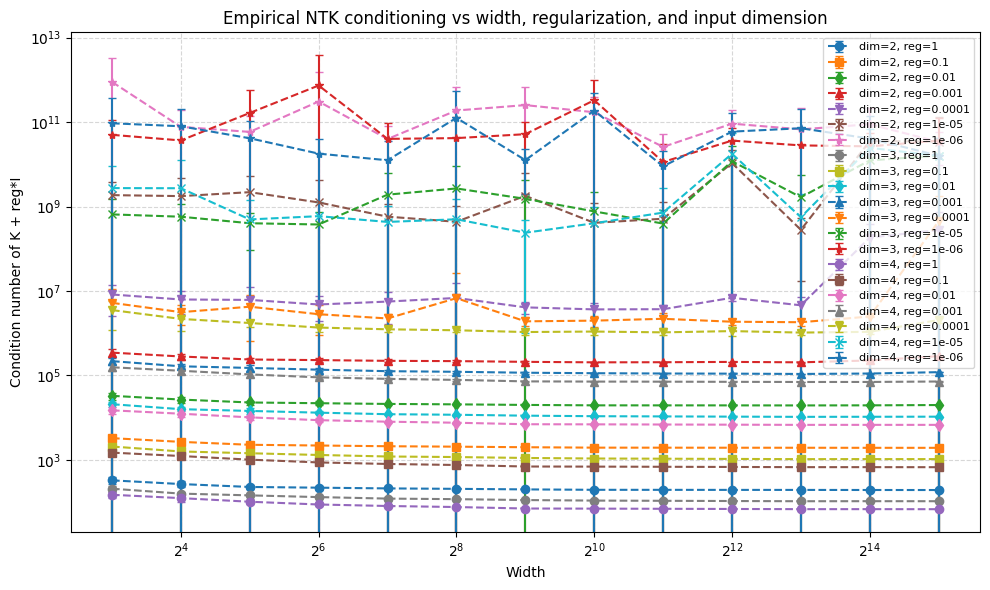

In [11]:
# ===========================
# User must define or import:
# x_train, x_test
# compute_empirical_ntk(apply_fn, params, x_train, x_test)
# ===========================

# Parameters
widths = [2**i for i in range(16)][3:]
n_seeds = 20  # increase for stability
num_class = 2
num_centers=400
dim_hypercube=2.0
num_points_per_task=1000
key = random.PRNGKey(0)
regs = [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
data_dims = [2, 3, 4]  # loop over these input dimensions

# Storage
conditioning_results = {dim: {reg: [] for reg in regs} for dim in data_dims}

for dim in data_dims:
    print(f"\n=== Data dimension = {dim} ===")

    for reg in regs:
        print(f"Processing regularization = {reg}")
        cond_means = []
        cond_stds = []

        pbar = tqdm(widths, desc=f"Reg={reg}, dim={dim}", leave=False)
        for width in pbar:
            cond_list = []
            keys = random.split(key, n_seeds)

            # Define NTK model
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            apply_fn = jit(apply_fn)
            kernel_fn = jit(kernel_fn, static_argnames=('get',))

            ds = make_multitask_classification_datasets(
                data_dim=dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,
                centers_per_task=num_centers,
                overlap=0.1,
                random_state=0,
                reuse=True
            )[0]

            X, y = ds['X'], ds['y']
            x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)
            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test = one_hot(y_test, num_class).astype(jnp.float32)

            for subkey in keys:
                _, params = init_fn(subkey, x_train.shape)

                # Compute empirical NTK
                K_train_train = compute_empirical_ntk(apply_fn, params, x_train, x_test)['train_train']

                # Ensure 4D shape for multi-class
                if K_train_train.ndim == 2:
                    K_train_train = jnp.stack([
                        jnp.stack([
                            K_train_train if i==j else jnp.zeros_like(K_train_train)
                            for j in range(C)], axis=-1)
                        for i in range(C)], axis=-2
                    )

                # Compute cond number per output, take max
                cond_per_output = []
                for out in range(C):
                    K_out = K_train_train[:, :, out, out]
                    cond_num = jnp.linalg.cond(K_out + reg*jnp.eye(K_out.shape[0]))
                    cond_per_output.append(cond_num)
                cond_list.append(float(jnp.max(jnp.array(cond_per_output))))

            cond_means.append(jnp.mean(jnp.array(cond_list)))
            cond_stds.append(jnp.std(jnp.array(cond_list)))

        conditioning_results[dim][reg] = {
            "widths": widths,
            "mean": cond_means,
            "std": cond_stds
        }

# Plotting
plt.figure(figsize=(10, 6))
markers = ["o", "s", "d", "^", "v", "x", "*"]

for dim in data_dims:
    for idx, reg in enumerate(regs):
        vals = conditioning_results[dim][reg]
        plt.errorbar(vals["widths"], vals["mean"], yerr=vals["std"],
                     label=f"dim={dim}, reg={reg}", marker=markers[idx % len(markers)], capsize=3, linestyle='--')

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Width")
plt.ylabel("Condition number of K + reg*I")
plt.title("Empirical NTK conditioning vs width, regularization, and input dimension")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


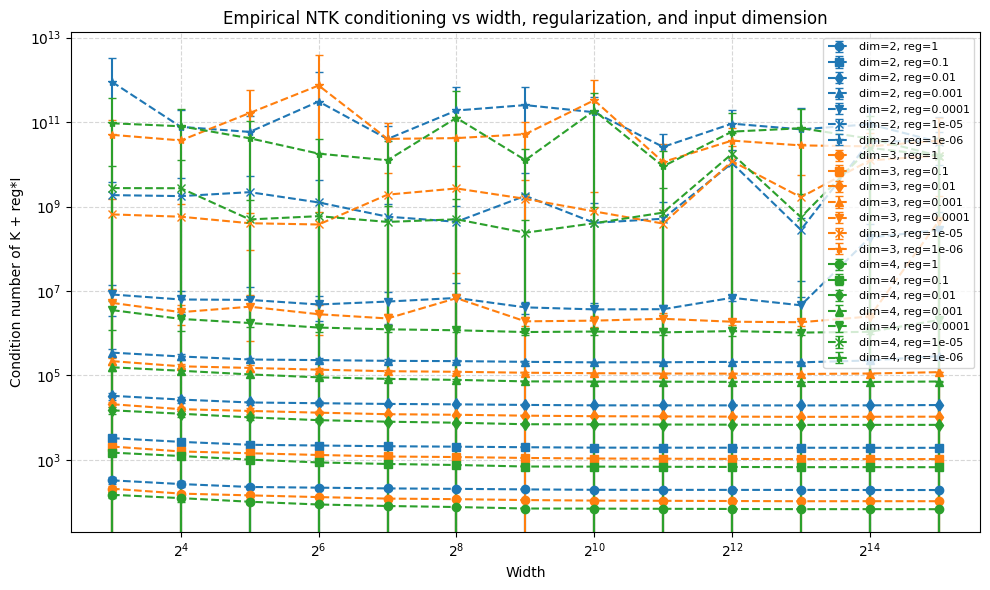

In [12]:
# Plotting with separate colors per dimension
plt.figure(figsize=(10, 6))
colors = ['C0', 'C1', 'C2', 'C3', 'C4']  # extend if more dims
markers = ["o", "s", "d", "^", "v", "x", "*"]

for dim_idx, dim in enumerate(data_dims):
    for idx, reg in enumerate(regs):
        vals = conditioning_results[dim][reg]
        plt.errorbar(vals["widths"], vals["mean"], yerr=vals["std"],
                     color=colors[dim_idx],
                     marker=markers[idx % len(markers)],
                     capsize=3,
                     linestyle='--',
                     label=f"dim={dim}, reg={reg}")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Width")
plt.ylabel("Condition number of K + reg*I")
plt.title("Empirical NTK conditioning vs width, regularization, and input dimension")
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
